In [1]:
# Zonal Averages for CAM and CESM climatological output

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob as glob

import importlib
import plot_2d_utils as putil

Case -  0  -  f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a
Case -  1  -  f.cam6_4_032.FLTHIST_ne30.cam7_ke.005b
Case -  2  -  f.cam6_4_032.FLTHIST_ne30.cam7_ke.006b
Case -  3  -  f.cam6_4_032.FLTHIST_ne30.cam7_ke.007b
Case -  4  -  f.cam6_4_032.FLTHIST_ne30.cam7_ke.009b


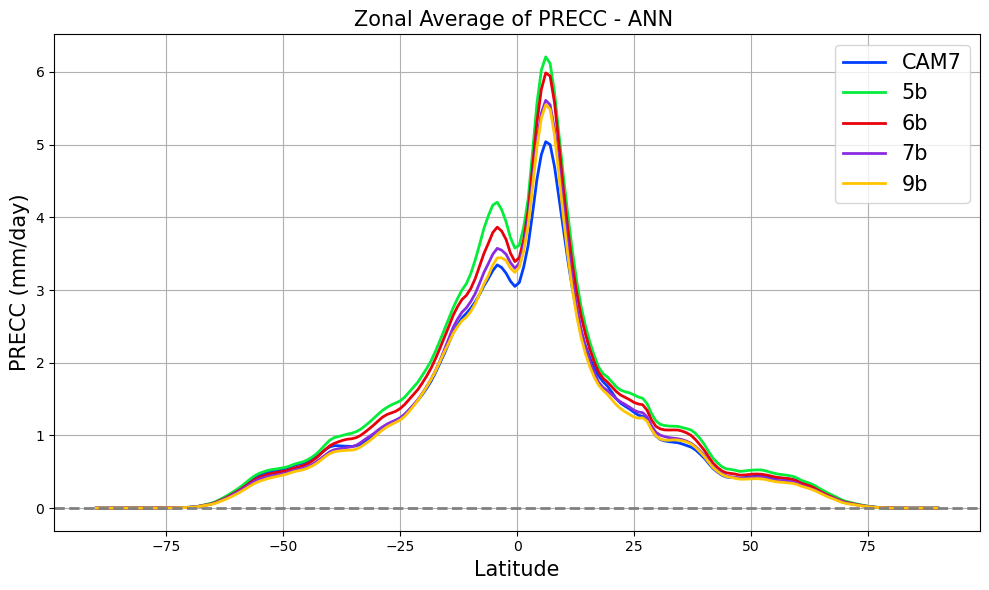

In [24]:
# Replace with your actual file paths and variable name
# Import
importlib.reload(putil) # Required because I am constantly editing scam_func.py


dir0 = "/glade/derecho/scratch/rneale/archive/"
dir_climo = '/glade/campaign/cgd/amp/amwg/climo/'
dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'
dir_fig = '/glade/u/home/rneale/python/python-figs/zm_dev/'


lfcase = True
lplatlon = True

if lfcase:

    fig_pref = "CAM7_zm_dmpdz_height_sens"
    
    cases = ['f.cam6_4_032.FLTHIST_ne30.cam7_ke.001a',
            'f.cam6_4_032.FLTHIST_ne30.cam7_ke.005b',
            'f.cam6_4_032.FLTHIST_ne30.cam7_ke.006b',
            'f.cam6_4_032.FLTHIST_ne30.cam7_ke.007b',
            'f.cam6_4_032.FLTHIST_ne30.cam7_ke.009b']
    
    case_names = ['CAM7','5b','6b','7b','9b']

else:

    fig_pref = "CESM3"
    
    cases = ['b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156', 
             'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.158',
             'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.160', 
             'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.162', 
             'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.163',
             'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.163']
  
    
    case_names = ["156","158","160","162","163","164"]

#cases = [cases[0]]
#case_names = [case_names[0]]


#var = "SHFLX" ; vname = "Sensible Heat Flux"  ; vscale = 1. ; vunits = "W/m^2" ; obs_cases = ['JRA25']
#var = "LHFLX" ; vname = "Latent Heat Flux"  ; vscale = 1. ; vunits = "W/m^2" ; obs_cases = ['ERAI', 'LARYEA','WHOI']
#var = "PRECT" ; vname = "Total Precipitation" ; vscale = 86400.*1000. ; vunits = "mm/day"; obs_cases = ['GPCP', 'TRMM']
#var = "PRECL" ; vname = "CLUBB Precipitation" ; vscale = 86400.*1000. ; vunits = "mm/day"; obs_cases = []
var = "PRECC" ; vname = "Convective Precipitation" ; vscale = 86400.*1000. ; vunits = "mm/day"; obs_cases = []
#var = "TMQ" ; vname = "Precipitable Water" ; vscale = 1. ; vunits = "mm"; obs_cases=['NVAP']
#var = "TAUX" ; vname = "Zonal Surface Stress" ; vscale = 1. ; vunits = "N/m^2"; obs_cases=['MERRA','JRA25','ERS']
#var = "TAUY" ; vname = "Meridonal Surface Stress" ; vscale = 1. ; vunits = "N/m^2"; obs_cases=['MERRA','JRA25','ERS']

seas = "ANN"

vmask_ocn = ['SHFLX','LHFLX','TAUX','TAUY']
#vmask_ocn = ['PRECT']
#vmask_ocn = []

cases.extend(obs_cases)
case_names.extend(obs_cases)




lstyles = ['-','--',':']

obs_set = ['GPCP','TRMM','ERAI','JRA25','MERRA','LARYEA','WHOI','NVAP','ERS','SSMI']


plt.figure(figsize=(10, 6))
#print(plt.style.available)
plt.style.use('seaborn-v0_8-bright')



lstyle = None
iobs = -1
mask_ocn = False

for icase, case in enumerate(cases):

    print("Case - ",icase," - ",case)
    
    if case in obs_set:
        iobs = iobs+1
        vscalex = 1.
        case_file = dir_obs+case+"_"+seas+"_climo.nc"
        lcol = 'k'
        lstyle = lstyles[iobs]
    else:
        if 'b.e30' in case:
            case_file = glob.glob(dir_climo+case+'/*/'+case+'_'+var+'_climo.nc')[0]  
        else:
            case_file = dir0+case+"/climo/"+case+"_"+seas+"_climo.nc"
            
        lcol = None
        vscalex = vscale 
    
    ds = xr.open_dataset(case_file,decode_times = False)
    
    
#    display(ds)
    
    # Extract the variable and select first time point

    vari = var
    vscalex = vscale

    if var == 'PRECT' and case in obs_cases:
        vscalex = 1.
    if case == 'LARYEA':
        vari = 'QFLX'
        vscalex = 28.93
    if case == 'NVAP':
        vari = 'PREH2O'
        vscalex = 1.
    if var in ['TAUX','TAUY'] and case in obs_cases:
        vscalex = -1.
    
    if ds.sizes.get('time') == 12:
        mon_index = putil.get_indexes(seas)
        ds = ds.sel(time=mon_index).mean(dim='time').squeeze()
    
    var_in = ds[vari].isel(time=0) if 'time' in ds[vari].dims else ds[vari]

    var_in = var_in*vscalex 
    
    if icase == 0:  
        if 'b.e30' in case:
            case_file = glob.glob(dir_climo+case+'/*/'+case+'_LANDFRAC_climo.nc')[0]  
            
            dlfrac = xr.open_dataset(case_file,decode_times = False)
            lmask = dlfrac['LANDFRAC'].isel(time=0) 
        else:
            lmask =  ds['LANDFRAC'].isel(time=0) if 'time' in ds['LANDFRAC'].dims else ds['LANDFRAC']

    if var in vmask_ocn:
      
        mask_ocn = True
        lmaski = lmask.interp_like(var_in)
        var_in = var_in.where(lmaski < 0.1)  # or lsm == False if it's a boolean mask
        
   
# Add in a 2D plot here?    

#    if lplatlon:
#            axl[icase].contourf(lonc, lat, pvarc, transform=pproj, cmap=cmap, extend=extend, levels=clevels)
            

    

    
    # Compute zonal mean (average over longitude)
    zonal_mean = var_in.mean(dim='lon', skipna=True)
    
    # Plot with latitude on the x-axis
    plt.plot(zonal_mean['lat'], zonal_mean, label=case_names[icase], linewidth=2,ls=lstyle,color=lcol)

    

    # Save off zonal means to plot as biases later maybe

#ß    zonal_means = 

fsize = 15
tocean = ' - Ocean' if mask_ocn else ''

plt.axhline(y=0, color='gray', linestyle='--', linewidth=2)
plt.xlabel('Latitude',fontsize=fsize)
plt.ylabel(var+' ('+vunits+')',fontsize=fsize)
plt.title(f'Zonal Average of {var} - {seas} {tocean}',fontsize=fsize)
plt.legend(fontsize=fsize)
plt.grid(True)
plt.tight_layout()

tocean = '_ocn_' if mask_ocn else ''
plt.savefig(dir_fig+fig_pref+"_zonal_ave_2d_"+var+"_"+seas+tocean+".png", dpi=120, bbox_inches="tight")
plt.show()